# Technical Background Exercises: ML-Based Intrusion Detection
**Name:** Nafisah Nubah  **ID:** B00961732  **Course:** CSCI 4192 (Directed Studies)

This notebook includes hands-on experimentation with a network intrusion-detection
dataset and a range of ML/DL models.

In [4]:
# Install required libraries
%pip install numpy pandas matplotlib seaborn scikit-learn torch

## 1. Setup

All randomness is seeded so the results are reproducible. Any transformation that learns from the data (scaling, encoding, feature selection) is fitted on the training set only and then applied to the test set, so that no information from the test set influences the models during training (Kaufman et al., 2012).

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

print("Libraries loaded. Random seed set to", RANDOM_SEED)

Libraries loaded. Random seed set to 42


## 2. Dataset

### 2.1 Choice of dataset
The experiments use [UNSW-NB15](https://research.unsw.edu.au/projects/unsw-nb15-dataset) (Moustafa and Slay, 2015), a widely used network intrusion dataset, through its official training and testing split. It contains a mix of normal traffic and nine modern attack families with realistic class imbalance, which makes it well suited to study how detection performance varies across common and rare attack types.

It was chosen over two common alternatives. NSL-KDD (Tavallaee et al., 2009) is smaller and cleaner but its attack types are dated, which limits how informative its results are for current threats. CIC-IDS2017 is larger but has documented labelling and quality issues that complicate analysis (Engelen et al., 2021). UNSW-NB15 offers a good balance of realism, size, and a ready-made train/test split that supports a fair evaluation.

### 2.2 Structure
The training set contains 175,341 records and the testing set contains 82,332 records, each with 45 columns: an `id`, 42 input features, a multiclass label `attack_cat`, and a binary label `label` (0 = normal, 1 = attack). The data spans ten classes (Normal plus nine attack categories).

In [6]:
# File Upload
import os

try:
    from google.colab import files
    print("Using Colab. Please upload UNSW_NB15_training-set.csv and UNSW_NB15_testing-set.csv")
    uploaded = files.upload()
    os.makedirs("data", exist_ok=True)
    for filename in uploaded.keys():
        os.rename(filename, os.path.join("data", filename))
        print(f"Moved '{filename}' to data/{filename}")

except ImportError:
    print("Not running in Colab. Expecting files in the data/ folder.")
    os.makedirs("data", exist_ok=True)

# Verify both files are present
expected = ["UNSW_NB15_training-set.csv", "UNSW_NB15_testing-set.csv"]
for f in expected:
    path = os.path.join("data", f)
    status = "FOUND" if os.path.exists(path) else "MISSING"
    print(f"  {path}: {status}")

Using Colab. Please upload UNSW_NB15_training-set.csv and UNSW_NB15_testing-set.csv


Saving UNSW_NB15_training-set.csv to UNSW_NB15_training-set.csv
Saving UNSW_NB15_testing-set.csv to UNSW_NB15_testing-set.csv
Moved 'UNSW_NB15_training-set.csv' to data/UNSW_NB15_training-set.csv
Moved 'UNSW_NB15_testing-set.csv' to data/UNSW_NB15_testing-set.csv
  data/UNSW_NB15_training-set.csv: FOUND
  data/UNSW_NB15_testing-set.csv: FOUND


In [7]:
DATA_DIR = Path("data")

df_train = pd.read_csv(DATA_DIR/"UNSW_NB15_training-set.csv")
df_test  = pd.read_csv(DATA_DIR/"UNSW_NB15_testing-set.csv")

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)

Train shape: (175341, 45)
Test shape : (82332, 45)


In [8]:
# Structural overview
print("Number of columns:", df_train.shape[1])
print("\nColumn names:\n", list(df_train.columns))
print("\nDtype counts:\n", df_train.dtypes.value_counts())

df_train.head()

Number of columns: 45

Column names:
 ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Dtype counts:
 int64      30
float64    11
object      4
Name: count, dtype: int64


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,0,0,24.295600,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,2,17,49.915000,15.432865,61.426934,1387.778330,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,252,1572.271851,60929.230470,1,6,231.875571,102.737203,17179.586860,11420.926230,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,252,2740.178955,3358.622070,1,3,152.876547,90.235726,259.080172,4991.784669,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,2,1,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,252,8561.499023,3987.059814,2,1,47.750333,75.659602,2415.837634,115.807000,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,43,1,2,2,1,40,0,0,0,2,39,0,Normal,0


### 2.3 Features
Following the dataset description (Moustafa and Slay, 2015), the features fall into a few groups:

- **Basic flow and connection features**, for example `dur` (duration), `spkts` and `dpkts` (packet counts), `sbytes` and `dbytes` (byte counts), `rate`, `proto`, `service`, and `state`.
- **Content features**, for example `trans_depth` and `response_body_len`.
- **Time features**, for example `sinpkt` and `dinpkt` (inter-packet times), `sjit` and `djit` (jitter), `tcprtt`, `synack`, and `ackdat`.
- **Connection counters** (the `ct_*` features) plus binary flags such as `is_ftp_login` and `is_sm_ips_ports`.

Three features are categorical (`proto`, `service`, `state`) and the rest are numeric. `id` is a row index and is dropped before modelling. `attack_cat` is the multiclass target and `label` is the binary target.

In [9]:
# Class distribution (attack_cat) and binary distribution (label)
print("attack_cat counts (train):")
print(df_train["attack_cat"].value_counts())

print("\nattack_cat proportion % (train):")
print((df_train["attack_cat"].value_counts(normalize=True)*100).round(2))

print("\nbinary label (train): 0 = normal, 1 = attack")
print(df_train["label"].value_counts())

counts = df_train["attack_cat"].value_counts()
print("\nImbalance ratio (largest : smallest attack_cat class) = {:.0f} : 1".format(counts.max()/counts.min()))

attack_cat counts (train):
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

attack_cat proportion % (train):
attack_cat
Normal            31.94
Generic           22.81
Exploits          19.04
Fuzzers           10.37
DoS                6.99
Reconnaissance     5.98
Analysis           1.14
Backdoor           1.00
Shellcode          0.65
Worms              0.07
Name: proportion, dtype: float64

binary label (train): 0 = normal, 1 = attack
label
1    119341
0     56000
Name: count, dtype: int64

Imbalance ratio (largest : smallest attack_cat class) = 431 : 1


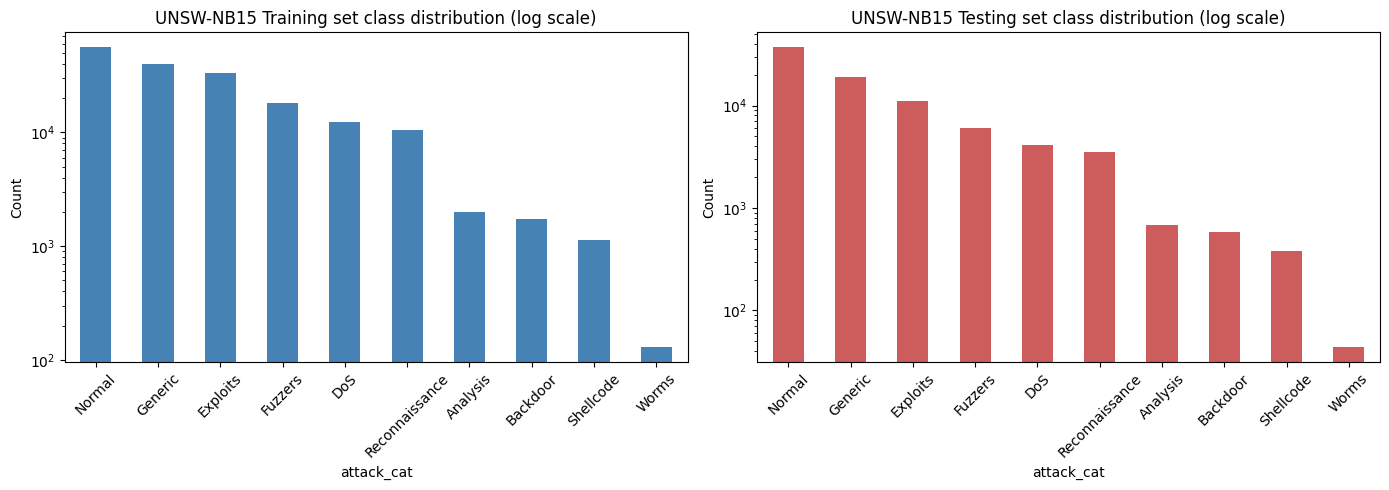

In [10]:
order = df_train["attack_cat"].value_counts().index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, name, color in [
    (axes[0], df_train, "Training", "steelblue"),
    (axes[1], df_test, "Testing", "indianred"),
]:
    df["attack_cat"].value_counts().reindex(order, fill_value=0).plot(kind="bar", ax=ax, color=color)
    ax.set_title(f"UNSW-NB15 {name} set class distribution (log scale)")
    ax.set_ylabel("Count")
    ax.set_yscale("log")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# Data quality checks
# Missing values
na = df_train.isnull().sum()
print("Missing values:", "none" if na.sum()==0 else f"\n{na[na>0]}")

# Duplicate rows
print("Duplicate rows:", df_train.duplicated().sum())

# Infinities in numeric columns
num_cols = df_train.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df_train[num_cols]).sum()
print("Columns with infinities:", "none" if (inf_counts>0).sum()==0 else f"\n{inf_counts[inf_counts>0]}")

# Categorical columns and their cardinalities
cat_cols = [c for c in df_train.select_dtypes(include="object").columns if c != "attack_cat"]
print("\nCategorical feature columns:", cat_cols)
for c in cat_cols:
    print(f"{c}: {df_train[c].nunique()} unique values")

Missing values: none
Duplicate rows: 0
Columns with infinities: none

Categorical feature columns: ['proto', 'service', 'state']
proto: 133 unique values
service: 13 unique values
state: 9 unique values


### 2.4 Findings
- There is severe class imbalance. The largest class outnumbers the smallest by about 431 to 1. Normal (31.9%), Generic (22.8%), and Exploits (19.0%) dominate, and Worms (0.07%), Shellcode (0.65%), and Backdoor (1.0%) are very rare. This makes it essential to assess per-class metrics, since overall accuracy can stay high while rare attacks go undetected.
- The categorical features (`proto` (133 values), `service` (13 values), and `state` (9 values)) need encoding.
- There are no missing values, no duplicate rows, and no infinite values, so no data cleaning is required.
- Numeric features span very different ranges, so features need to be standardised for the scale-sensitive models.

## 3. Preprocessing

Each preprocessing step follows directly from the findings above. All steps that learn from the data are fitted on the training set only and then applied to the test set, to prevent information leakage (Kaufman et al., 2012).

- The `id` column is dropped, as it is only a row index.
- The three categorical features are one-hot encoded, with unknown categories handled safely so that any protocol or service appearing only in the test set does not break inference.
- Numeric features are standardised to zero mean and unit variance.
- Class imbalance is handled at model training time through class weighting and reported through per-class metrics.
- Both labels are kept and each model is tested on a binary task (Normal vs Attack) and a ten-class task (attack family).

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

# Define columns
drop_cols = ["id", "attack_cat", "label"]
categorical_cols = ["proto", "service", "state"]
numeric_cols = [c for c in df_train.columns if c not in drop_cols + categorical_cols]

# Separate features from targets
X_train_raw = df_train.drop(columns=drop_cols)
X_test_raw = df_test.drop(columns=drop_cols)

# Binary targets (0 = normal, 1 = attack)
y_train_bin = df_train["label"].values
y_test_bin = df_test["label"].values

# Class targets: encode class names to integers
le = LabelEncoder()
y_train_multi = le.fit_transform(df_train["attack_cat"])
y_test_multi = le.transform(df_test["attack_cat"])
class_names = le.classes_

print(f"Numeric features : {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print("\nMulticlass label mapping (integer to class):")
for i, name in enumerate(class_names):
    print(f"{i} - {name}")

Numeric features : 39
Categorical features: 3

Multiclass label mapping (integer to class):
0 - Analysis
1 - Backdoor
2 - DoS
3 - Exploits
4 - Fuzzers
5 - Generic
6 - Normal
7 - Reconnaissance
8 - Shellcode
9 - Worms


In [13]:
import numpy as np

# Build the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ],
    remainder="drop",
)

# Fit on train only, then apply to both
X_train = preprocessor.fit_transform(X_train_raw).astype(np.float32)
X_test = preprocessor.transform(X_test_raw).astype(np.float32)   # float32 saves memory

# Recover output feature names
feature_names = preprocessor.get_feature_names_out()

print("Processed train shape:", X_train.shape)
print("Processed test shape:", X_test.shape)
print("Total features after encoding:", len(feature_names))
print(f"({len(numeric_cols)} numeric + one-hot expansion of proto/service/state)")

Processed train shape: (175341, 194)
Processed test shape: (82332, 194)
Total features after encoding: 194
(39 numeric + one-hot expansion of proto/service/state)


### 3.1 Resulting feature space
After encoding, the feature count grows from 42 to 194 (39 standardised numeric features plus one-hot columns for `proto`, `service`, and `state`). The processed training and testing matrices have shapes (175341, 194) and (82332, 194).

## 4. Exploratory Data Analysis

This is a brief, diagnostic look at the processed training data. The purpose is to set expectations before modelling: to see which features carry the most information about the attack class, and how separable the classes are. These observations help explain the model results that follow.

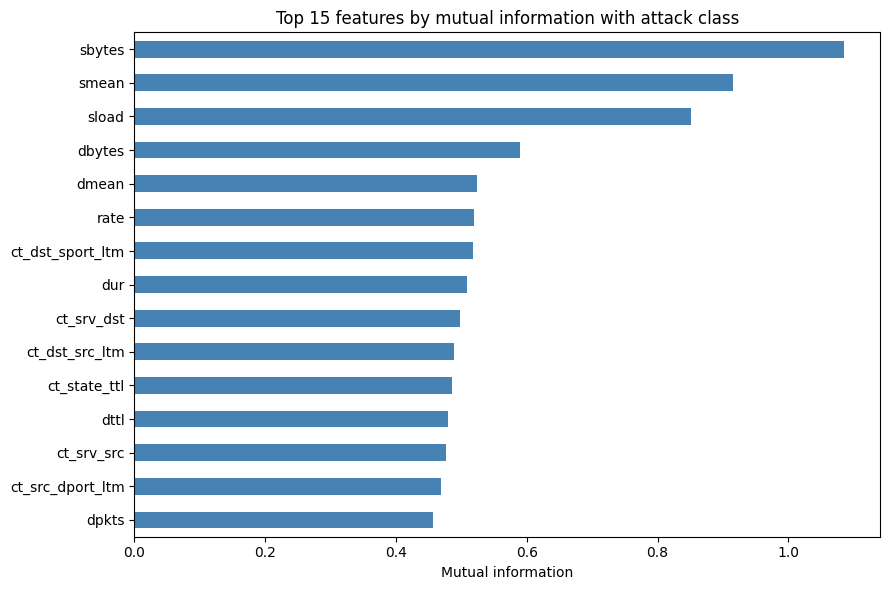

Top 15 features by mutual information:
sbytes              1.0859
smean               0.9158
sload               0.8509
dbytes              0.5889
dmean               0.5236
rate                0.5185
ct_dst_sport_ltm    0.5175
dur                 0.5082
ct_srv_dst          0.4972
ct_dst_src_ltm      0.4886
ct_state_ttl        0.4857
dttl                0.4797
ct_srv_src          0.4762
ct_src_dport_ltm    0.4686
dpkts               0.4572
dtype: float64


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

# Clean encoder prefixes for readability
clean_names = [f.split("__", 1)[-1] for f in feature_names]

rng = np.random.RandomState(RANDOM_SEED)
sub_idx = rng.choice(X_train.shape[0], size=20000, replace=False)

mi = mutual_info_classif(X_train[sub_idx], y_train_multi[sub_idx], random_state=RANDOM_SEED)
mi_series = pd.Series(mi, index=clean_names).sort_values(ascending=False)

top_n = 15
plt.figure(figsize=(9, 6))
mi_series.head(top_n)[::-1].plot(kind="barh", color="steelblue")
plt.title(f"Top {top_n} features by mutual information with attack class")
plt.xlabel("Mutual information")
plt.tight_layout()
plt.show()

print("Top 15 features by mutual information:")
print(mi_series.head(15).round(4))

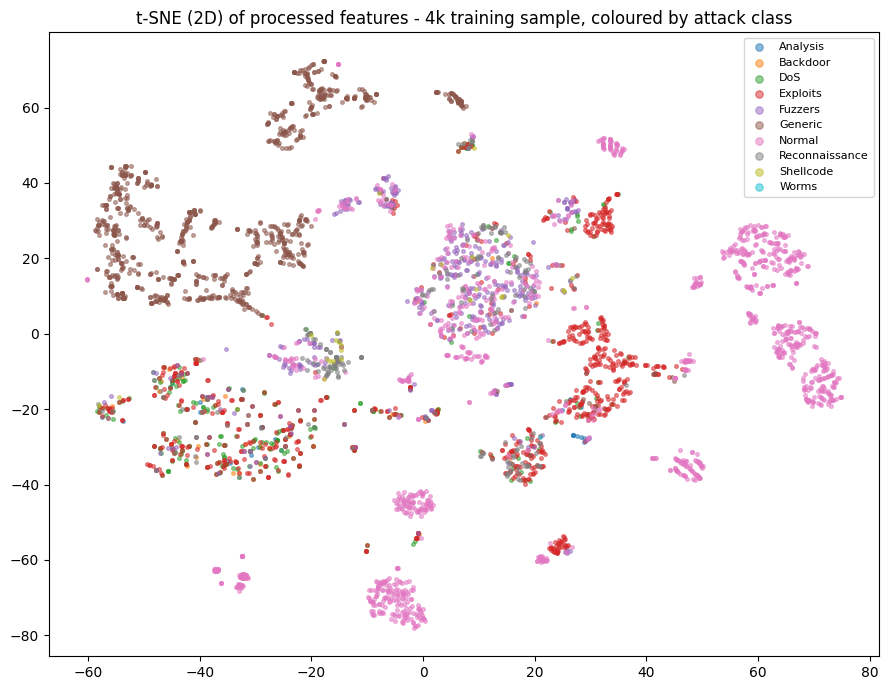

In [15]:
from sklearn.manifold import TSNE

# Use a 4k random subsample
rng = np.random.RandomState(RANDOM_SEED)
tsne_idx = rng.choice(X_train.shape[0], size=4000, replace=False)

X_tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=RANDOM_SEED).fit_transform(X_train[tsne_idx])

plt.figure(figsize=(9, 7))
for cls_int in np.unique(y_train_multi):
    m = y_train_multi[tsne_idx]==cls_int
    plt.scatter(X_tsne[m, 0], X_tsne[m, 1], s=7, alpha=0.5, label=class_names[cls_int])
plt.title("t-SNE (2D) of processed features - 4k training sample, coloured by attack class")
plt.legend(markerscale=2, fontsize=8, loc="best")
plt.tight_layout()
plt.show()

### 4.1 Findings

- A few features carry most of the signal. Mutual information with the attack class is dominated by a small group of source-side volume features, led by `sbytes` (1.09), `smean` (0.92), and `sload` (0.85), followed by `dbytes`, `dmean`, `rate`, and several connection counters. This concentration of signal helps explain why simple models can perform well, and it motivates the feature-selection step used later for the Transformer.
- In the t-SNE projection the large classes (Generic, Normal, Exploits) form fairly distinct clusters, while the rare classes (Worms, Shellcode, Analysis, Backdoor) do not form clear regions of their own. This is partly because they have very few samples, but the model results in Section 5 show evidence of overlap between large and small classes: rare-class samples are actively misclassified as specific larger attack types. Either way, this suggests that rare classes would be the hardest to detect.

## 5. Baseline Models

This section establishes baselines that more complex models are measured against later. Two models are used:

- **Logistic Regression**, a simple linear model used as a reference point.
- **Random Forest**, a strong and well-established classifier for network intrusion detection (Farnaaz and Jabbar, 2016), used as the main bar that more complex models must beat to justify their cost.

Both are run on the binary task (Normal vs Attack) and the ten-class task (attack family), and both use balanced class weighting so the heavy imbalance does not push the models to ignore rare classes. Because of that imbalance, the main metrics used are macro-F1 and per-class recall rather than accuracy, and also the false positive rate (FPR), which reflects how often normal traffic is wrongly flagged.

In [16]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix)
import numpy as np

results = []

def false_positive_rate(y_true, y_pred, normal_label):
    is_normal = (y_true==normal_label)        # true normals
    flagged_attack = (y_pred != normal_label)        # predicted as some attack
    tn = np.sum(is_normal & (y_pred==normal_label))
    fp = np.sum(is_normal & flagged_attack)
    return fp/(fp+tn) if (fp+tn)>0 else 0.0

def evaluate_model(name, task, y_true, y_pred, target_names=None, normal_label=None):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    macro_p = precision_score(y_true, y_pred, average="macro", zero_division=0)
    macro_r = recall_score(y_true, y_pred, average="macro", zero_division=0)
    fpr = false_positive_rate(y_true, y_pred, normal_label) if normal_label is not None else np.nan

    results.append({"Model": name, "Task": task, "Accuracy": acc, "Macro-F1": macro_f1, "Macro-Precision": macro_p, "Macro-Recall": macro_r, "FPR": fpr})

    print(f"\n{'='*60}\n{name}  -  {task}\n{'='*60}")
    print(f"Accuracy={acc:.4f} | Macro-F1={macro_f1:.4f} | "
          f"Macro-P={macro_p:.4f} | Macro-R={macro_r:.4f} | FPR={fpr:.4f}")
    print("\nPer-class report:")
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))
    return confusion_matrix(y_true, y_pred)

In [17]:
from sklearn.linear_model import LogisticRegression

# Binary
logreg_bin = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
logreg_bin.fit(X_train, y_train_bin)
cm_lr_bin = evaluate_model("Logistic Regression", "Binary", y_test_bin, logreg_bin.predict(X_test), target_names=["Normal", "Attack"], normal_label=0)

# Multiclass
logreg_multi = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
logreg_multi.fit(X_train, y_train_multi)
cm_lr_multi = evaluate_model("Logistic Regression", "Multiclass", y_test_multi, logreg_multi.predict(X_test), target_names=class_names, normal_label=6)


Logistic Regression  -  Binary
Accuracy=0.8355 | Macro-F1=0.8293 | Macro-P=0.8485 | Macro-R=0.8247 | FPR=0.2821

Per-class report:
              precision    recall  f1-score   support

      Normal       0.90      0.72      0.80     37000
      Attack       0.80      0.93      0.86     45332

    accuracy                           0.84     82332
   macro avg       0.85      0.82      0.83     82332
weighted avg       0.84      0.84      0.83     82332


Logistic Regression  -  Multiclass
Accuracy=0.6203 | Macro-F1=0.3517 | Macro-P=0.3960 | Macro-R=0.5483 | FPR=0.4209

Per-class report:
                precision    recall  f1-score   support

      Analysis       0.06      0.57      0.11       677
      Backdoor       0.03      0.17      0.05       583
           DoS       0.41      0.14      0.21      4089
      Exploits       0.80      0.45      0.58     11132
       Fuzzers       0.27      0.64      0.38      6062
       Generic       1.00      0.96      0.98     18871
        Norm

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Binary
rf_bin = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
rf_bin.fit(X_train, y_train_bin)
cm_rf_bin = evaluate_model("Random Forest", "Binary", y_test_bin, rf_bin.predict(X_test), target_names=["Normal", "Attack"], normal_label=0)

# Multiclass
rf_multi = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
rf_multi.fit(X_train, y_train_multi)
cm_rf_multi = evaluate_model("Random Forest", "Multiclass", y_test_multi, rf_multi.predict(X_test), target_names=class_names, normal_label=6)


Random Forest  -  Binary
Accuracy=0.8714 | Macro-F1=0.8652 | Macro-P=0.8980 | Macro-R=0.8584 | FPR=0.2702

Per-class report:
              precision    recall  f1-score   support

      Normal       0.98      0.73      0.84     37000
      Attack       0.82      0.99      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.90      0.86      0.87     82332
weighted avg       0.89      0.87      0.87     82332


Random Forest  -  Multiclass
Accuracy=0.7481 | Macro-F1=0.4895 | Macro-P=0.5243 | Macro-R=0.5119 | FPR=0.2343

Per-class report:
                precision    recall  f1-score   support

      Analysis       0.02      0.04      0.03       677
      Backdoor       0.03      0.26      0.06       583
           DoS       0.30      0.21      0.25      4089
      Exploits       0.73      0.67      0.70     11132
       Fuzzers       0.29      0.57      0.39      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.9

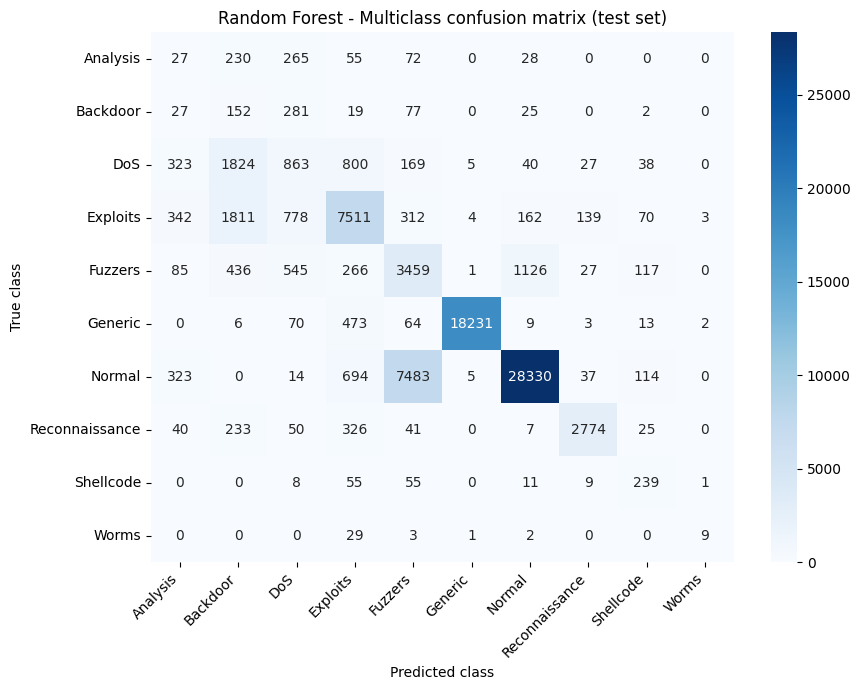

In [19]:
import seaborn as sns

plt.figure(figsize=(9, 7))
sns.heatmap(cm_rf_multi, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Random Forest - Multiclass confusion matrix (test set)")
plt.ylabel("True class"); plt.xlabel("Predicted class")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.1 Results

| Model | Task | Accuracy | Macro-F1 | Macro-Recall | FPR |
|---|---|---|---|---|---|
| Logistic Regression | Binary | 0.836 | 0.829 | 0.825 | 0.282 |
| Random Forest | Binary | 0.871 | 0.865 | 0.858 | 0.270 |
| Logistic Regression | Multiclass | 0.620 | 0.352 | 0.548 | 0.421 |
| Random Forest | Multiclass | 0.748 | 0.490 | 0.512 | 0.234 |

Random Forest outperforms Logistic Regression on both tasks, confirming it as the stronger baseline (Farnaaz and Jabbar, 2016).

Accuracy is a poor measure of multiclass performance. Random Forest reaches 0.748 accuracy but only 0.490 macro-F1 due to class imbalance. This is why accuracy is not used as the main metric.

Per-class results are very uneven and match the Section 4 observations. The well-separated large classes score highly (Generic F1 = 0.98, Normal = 0.85, Reconnaissance = 0.85), and the overlapping rare families score low (Analysis = 0.03, Backdoor = 0.06, DoS = 0.25, Worms = 0.31). The confusion matrix shows that these classes are mostly absorbed into Exploits, DoS, and Fuzzers, so distinguishing between similar attack types is also challenging.

## 6. Hybrid CNN-LSTM: Effect of Architectural Depth

This section tests a deep hybrid model and checks whether added depth improves detection on this dataset. Two CNN-LSTM models are built following the hybrid design of Halbouni et al. (2022), where convolutional layers extract spatial feature patterns and an LSTM layer models them as a sequence, with batch normalisation and dropout for stability:

- Model 1 (Simple): one CNN and LSTM block
- Model 2 (Deep): three stacked CNN and LSTM blocks

Both models use the same optimiser, learning rate, batch size, and number of epochs, so the only thing that changes is depth. This makes the comparison fair and isolates the effect of model capacity. The goal is to see whether depth helps, and how both models compare against the Random Forest baseline.

In [20]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
torch.manual_seed(RANDOM_SEED)

# Features
Xtr_full = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
Xte = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1)

# Use 10% from training set as validation set to watch for overfitting
def make_loader(X, y, batch=512, shuffle=False):
    ds = TensorDataset(X, torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch, shuffle=shuffle)

def class_weights(y):
    counts = np.bincount(y)
    w = len(y)/(len(counts)*counts)
    return torch.tensor(w, dtype=torch.float32).to(device)

# Training config, identical for both models
CFG = dict(lr=1e-3, batch=512, epochs=15)
print("Shared training config:", CFG)

Using device: cuda
Shared training config: {'lr': 0.001, 'batch': 512, 'epochs': 15}


In [21]:
# Model 1: Simple (one CNN+LSTM block)
class CNN_LSTM_Simple(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 64, 3, padding=1), nn.ReLU(), nn.BatchNorm1d(64), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=1), nn.ReLU(), nn.BatchNorm1d(128), nn.MaxPool1d(2),
        )                                       # -> (batch, 128, 48)
        self.lstm = nn.LSTM(128, 64, batch_first=True)
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(64, n_classes))

    def forward(self, x):
        x = self.conv(x).permute(0, 2, 1)
        _, (h, _) = self.lstm(x)
        return self.head(h[-1])


# Model 2: Deeper (three CNN+LSTM blocks)
class CNNLSTMBlock(nn.Module):
    def __init__(self, in_ch, conv_ch, lstm_hidden, pool=True):
        super().__init__()
        layers = [nn.Conv1d(in_ch, conv_ch, 3, padding=1), nn.ReLU(), nn.BatchNorm1d(conv_ch)]
        if pool:
            layers.append(nn.MaxPool1d(2))
        self.conv = nn.Sequential(*layers)
        self.lstm = nn.LSTM(conv_ch, lstm_hidden, batch_first=True)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.conv(x).permute(0, 2, 1)
        seq, _ = self.lstm(x)
        return self.dropout(seq).permute(0, 2, 1)

class CNN_LSTM_Deep(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.block1 = CNNLSTMBlock(1, 64, 64, pool=True)
        self.block2 = CNNLSTMBlock(64, 128, 128, pool=True)
        self.block3 = CNNLSTMBlock(128, 128, 64, pool=False)
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(64, n_classes))

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x).permute(0, 2, 1)
        return self.head(x[:, -1, :])

In [22]:
def train_eval(model_cls, name, y_tr_full, y_te, task, target_names, normal_label):
    n_classes = len(np.unique(y_tr_full))

    idx = np.arange(len(y_tr_full))
    tr_idx, va_idx = train_test_split(idx, test_size=0.10, stratify=y_tr_full, random_state=RANDOM_SEED)
    tr_loader = make_loader(Xtr_full[tr_idx], y_tr_full[tr_idx], CFG["batch"], shuffle=True)
    va_loader = make_loader(Xtr_full[va_idx], y_tr_full[va_idx], CFG["batch"])

    model = model_cls(X_train.shape[1], n_classes).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=CFG["lr"])
    crit = nn.CrossEntropyLoss(weight=class_weights(y_tr_full[tr_idx]))

    print(f"\nTraining {name} ({task})")
    for ep in range(CFG["epochs"]):
        model.train(); tr_loss = 0
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
            tr_loss += loss.item()
        # validation loss
        model.eval(); va_loss = 0
        with torch.no_grad():
            for xb, yb in va_loader:
                xb, yb = xb.to(device), yb.to(device)
                va_loss += crit(model(xb), yb).item()
        if (ep+1)%3==0 or ep==0:
            print(f"epoch {ep+1:2d}/{CFG['epochs']}  "
                  f"train={tr_loss/len(tr_loader):.4f}  val={va_loss/len(va_loader):.4f}")

    # Test prediction
    model.eval(); preds = []
    with torch.no_grad():
        for xb, _ in make_loader(Xte, y_te):
            preds.append(model(xb.to(device)).argmax(1).cpu().numpy())
    y_pred = np.concatenate(preds)
    cm = evaluate_model(name, task, y_te, y_pred, target_names=target_names, normal_label=normal_label)
    return cm

# Run both models for both tasks
train_eval(CNN_LSTM_Simple, "CNN-LSTM (Simple)", y_train_bin, y_test_bin, "Binary", ["Normal", "Attack"], normal_label=0)
train_eval(CNN_LSTM_Deep, "CNN-LSTM (Deep)", y_train_bin, y_test_bin, "Binary", ["Normal", "Attack"], normal_label=0)

cm_simple_multi = train_eval(CNN_LSTM_Simple, "CNN-LSTM (Simple)", y_train_multi, y_test_multi, "Multiclass", class_names, normal_label=6)
cm_deep_multi = train_eval(CNN_LSTM_Deep, "CNN-LSTM (Deep)", y_train_multi, y_test_multi, "Multiclass", class_names, normal_label=6)


Training CNN-LSTM (Simple) (Binary)
epoch  1/15  train=0.3766  val=0.1847
epoch  3/15  train=0.1502  val=0.1379
epoch  6/15  train=0.1335  val=0.1280
epoch  9/15  train=0.1266  val=0.1209
epoch 12/15  train=0.1227  val=0.1242
epoch 15/15  train=0.1202  val=0.1241

CNN-LSTM (Simple)  -  Binary
Accuracy=0.8774 | Macro-F1=0.8722 | Macro-P=0.8990 | Macro-R=0.8658 | FPR=0.2495

Per-class report:
              precision    recall  f1-score   support

      Normal       0.97      0.75      0.85     37000
      Attack       0.83      0.98      0.90     45332

    accuracy                           0.88     82332
   macro avg       0.90      0.87      0.87     82332
weighted avg       0.89      0.88      0.87     82332


Training CNN-LSTM (Deep) (Binary)
epoch  1/15  train=0.3925  val=0.2046
epoch  3/15  train=0.1494  val=0.1399
epoch  6/15  train=0.1357  val=0.1296
epoch  9/15  train=0.1275  val=0.1256
epoch 12/15  train=0.1244  val=0.1214
epoch 15/15  train=0.1218  val=0.1286

CNN-LSTM (Deep

In [23]:
results_df = pd.DataFrame(results)

compare = results_df[results_df["Model"].isin(["Random Forest", "CNN-LSTM (Simple)", "CNN-LSTM (Deep)"])]
compare = compare.sort_values(["Task", "Macro-F1"], ascending=[True, False])
print(compare.to_string(index=False, columns=["Task", "Model", "Accuracy", "Macro-F1", "Macro-Recall", "FPR"], float_format=lambda x: f"{x:.4f}"))

      Task             Model  Accuracy  Macro-F1  Macro-Recall    FPR
    Binary   CNN-LSTM (Deep)    0.9081    0.9068        0.9055 0.1199
    Binary CNN-LSTM (Simple)    0.8774    0.8722        0.8658 0.2495
    Binary     Random Forest    0.8714    0.8652        0.8584 0.2702
Multiclass     Random Forest    0.7481    0.4895        0.5119 0.2343
Multiclass CNN-LSTM (Simple)    0.6069    0.3374        0.5319 0.4193
Multiclass   CNN-LSTM (Deep)    0.6059    0.3082        0.4374 0.4216


In [24]:
# Free the full-dataset CNN-LSTM tensors since they are no longer needed
import gc
del Xtr_full, Xte
gc.collect()
print("Freed Xtr_full and Xte.")

Freed Xtr_full and Xte.


### 6.1 Results

| Task | Model | Accuracy | Macro-F1 | Macro-Recall | FPR |
|---|---|---|---|---|---|
| Binary | CNN-LSTM (Deep) | 0.908 | 0.907 | 0.906 | 0.120 |
| Binary | CNN-LSTM (Simple) | 0.877 | 0.872 | 0.866 | 0.250 |
| Binary | Random Forest | 0.871 | 0.865 | 0.858 | 0.270 |
| Multiclass | Random Forest | 0.748 | 0.490 | 0.512 | 0.234 |
| Multiclass | CNN-LSTM (Simple) | 0.607 | 0.337 | 0.532 | 0.419 |
| Multiclass | CNN-LSTM (Deep) | 0.606 | 0.308 | 0.437 | 0.422 |

The effect of depth depends on the task. On the binary task, depth clearly helps: the deep model reaches the best macro-F1 (0.907) and the lowest FPR (0.120), beating both the simple model and Random Forest.

On the multiclass task this is the opposite. Both hybrid models fall well below Random Forest, and the deeper model is the weakest of all (macro-F1 0.308), despite having about four times the parameters of the simple one (Section 9.3). Under fixed conditions, added depth did not improve fine-grained attack classification and in fact slightly hurt it. This shows that more capacity is not the bottleneck for this problem.

## 7. Hierarchical Detection and Zero-Day Generalization

Section 5 showed that a single flat model struggles with rare, overlapping attack families. This section tests two designs that target that weakness, both inspired by the two-tier, one-class idea of Uddin et al. (2024):

- Supervised two-tier classifier: split detection into an easy first decision (Normal vs Attack) and a second decision (which attack family), to test whether decomposition helps detect rare classes
- Autoencoder one-class detector: a detector trained on normal traffic only, to test how well attacks can be caught when no attack samples are used in training, which directly translates to the detection of unseen, zero-day-style attacks

### 7.1 Supervised two-tier classifier

This is a cascade of two Random Forests, following the layered detection idea of Uddin et al. (2024). Tier 1 is the binary Random Forest from Section 5 (Normal vs Attack). Tier 2 is a Random Forest trained only on attack samples, so it specialises in telling attack families apart. At test time, Tier 1 runs first, and only samples it flags as attacks are passed to Tier 2 for classification. The purpose is to test whether separating the two decisions improves rare-class detection. 

Note: Any attack Tier 1 misses never reaches Tier 2, so Tier 1's attack recall sets an upper limit on the cascade.

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Tier 2: multiclass RF on attack samples only
attack_mask_tr = (y_train_multi != 6)
rf_tier2 = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
rf_tier2.fit(X_train[attack_mask_tr], y_train_multi[attack_mask_tr])

# Tier 1: binary RF
tier1_pred = rf_bin.predict(X_test)
tier2_pred = rf_tier2.predict(X_test)
final_pred = np.where(tier1_pred==1, tier2_pred, 6)

true_attacks = (y_test_multi != 6)
print(f"Tier 1 attack recall (real attacks passed to Tier 2): "
      f"{(tier1_pred[true_attacks]==1).mean():.3f}\n")

cm_twotier = evaluate_model("Two-Tier RF", "Multiclass", y_test_multi, final_pred, target_names=class_names, normal_label=6)

Tier 1 attack recall (real attacks passed to Tier 2): 0.987


Two-Tier RF  -  Multiclass
Accuracy=0.7401 | Macro-F1=0.4862 | Macro-P=0.5378 | Macro-R=0.5113 | FPR=0.2702

Per-class report:
                precision    recall  f1-score   support

      Analysis       0.02      0.04      0.03       677
      Backdoor       0.03      0.24      0.05       583
           DoS       0.30      0.21      0.25      4089
      Exploits       0.72      0.68      0.70     11132
       Fuzzers       0.30      0.68      0.42      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.98      0.73      0.84     37000
Reconnaissance       0.93      0.79      0.86      3496
     Shellcode       0.43      0.64      0.51       378
         Worms       0.67      0.14      0.23        44

      accuracy                           0.74     82332
     macro avg       0.54      0.51      0.49     82332
  weighted avg       0.85      0.74      0.78     82332



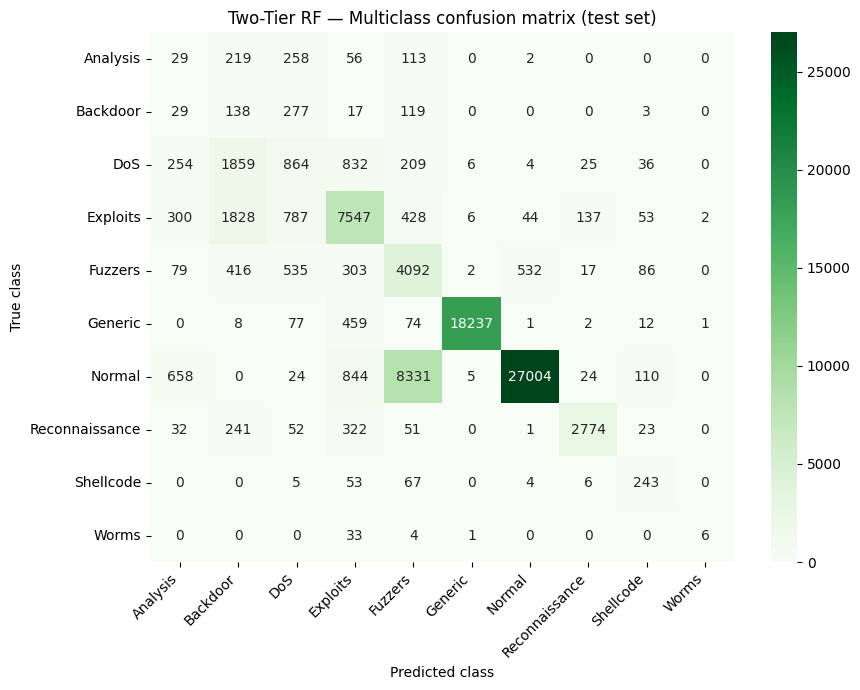

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))
sns.heatmap(cm_twotier, annot=True, fmt="d", cmap="Greens", xticklabels=class_names, yticklabels=class_names)
plt.title("Two-Tier RF — Multiclass confusion matrix (test set)")
plt.ylabel("True class"); plt.xlabel("Predicted class")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

#### 7.1 Results

| Model | Accuracy | Macro-F1 | Macro-Recall | FPR |
|---|---|---|---|---|
| Flat Random Forest (Section 5) | 0.748 | 0.490 | 0.512 | 0.234 |
| Two-Tier RF | 0.740 | 0.486 | 0.511 | 0.270 |

Tier 1 passed 98.7% of real attacks through to Tier 2, so almost no attacks were lost at the first stage. Even so, the two-tier model performed essentially the same as the flat Random Forest (macro-F1 0.486 vs 0.490), and the rare classes remained weak.

This shows that, because Tier 1 already separates Normal from Attack very well, the real difficulty was never that first decision but the confusion between similar attack families, which Tier 2 inherits unchanged. Splitting the problem into two stages does not, by itself, solve rare-class detection.

### 7.2 Autoencoder one-class detector

This detector is trained to reconstruct normal traffic only. At test time, attacks reconstruct poorly and produce high reconstruction error, so samples above an error threshold are flagged as anomalies. This is the standard autoencoder approach to anomaly-based intrusion detection, where a model trained on normal traffic identifies attacks through reconstruction error (Sadaf and Sultana, 2020), and it follows the normal-only first stage of Uddin et al. (2024).

The threshold is set from the reconstruction errors of the normal traffic in the training set (the 95th percentile, a target false positive rate of about 5%) and then applied unchanged to the test set. Since the model never sees any attack during training, every attack family is effectively unseen, so per-family detection rates measure how well genuinely new attacks are caught.

In [27]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(RANDOM_SEED)

class AutoEncoder(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, n_features),
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

# Train on benign training samples only
normal_mask_tr = (y_train_bin==0)
X_normal = torch.tensor(X_train[normal_mask_tr], dtype=torch.float32)
loader = DataLoader(TensorDataset(X_normal), batch_size=512, shuffle=True)

ae = AutoEncoder(X_train.shape[1]).to(device)
opt = torch.optim.Adam(ae.parameters(), lr=1e-3)
crit = nn.MSELoss()

print("Training autoencoder on benign traffic only...")
ae.train()
for ep in range(20):
    tot = 0
    for (xb,) in loader:
        xb = xb.to(device)
        opt.zero_grad()
        loss = crit(ae(xb), xb)
        loss.backward(); opt.step()
        tot += loss.item()
    if (ep+1)%5==0 or ep==0:
        print(f"epoch {ep+1:2d}/20  recon-loss={tot/len(loader):.5f}")

Training autoencoder on benign traffic only...
epoch  1/20  recon-loss=0.16200
epoch  5/20  recon-loss=0.01384
epoch 10/20  recon-loss=0.00563
epoch 15/20  recon-loss=0.00394
epoch 20/20  recon-loss=0.00307


In [28]:
def recon_error(model, X):
    model.eval()
    errs = []
    with torch.no_grad():
        for i in range(0, len(X), 4096):
            xb = torch.tensor(X[i:i+4096], dtype=torch.float32).to(device)
            err = ((model(xb)-xb)**2).mean(dim=1).cpu().numpy()
            errs.append(err)
    return np.concatenate(errs)

train_normal_err = recon_error(ae, X_train[normal_mask_tr])
threshold = np.percentile(train_normal_err, 95)

test_err = recon_error(ae, X_test)
y_pred_ae = (test_err>threshold).astype(int)

print(f"Reconstruction-error threshold (from train normals): {threshold:.5f}\n")
cm_ae = evaluate_model("Autoencoder (one-class)", "Binary", y_test_bin, y_pred_ae, target_names=["Normal", "Attack"], normal_label=0)

Reconstruction-error threshold (from train normals): 0.00952


Autoencoder (one-class)  -  Binary
Accuracy=0.8434 | Macro-F1=0.8434 | Macro-P=0.8479 | Macro-R=0.8502 | FPR=0.0835

Per-class report:
              precision    recall  f1-score   support

      Normal       0.78      0.92      0.84     37000
      Attack       0.92      0.78      0.85     45332

    accuracy                           0.84     82332
   macro avg       0.85      0.85      0.84     82332
weighted avg       0.86      0.84      0.84     82332



                Support  Detected as anomaly
Class                                       
Analysis            677                0.999
Backdoor            583                0.928
DoS                4089                0.873
Exploits          11132                0.828
Fuzzers            6062                0.347
Generic           18871                0.984
Normal            37000                0.084
Reconnaissance     3496                0.236
Shellcode           378                0.019
Worms                44                0.705


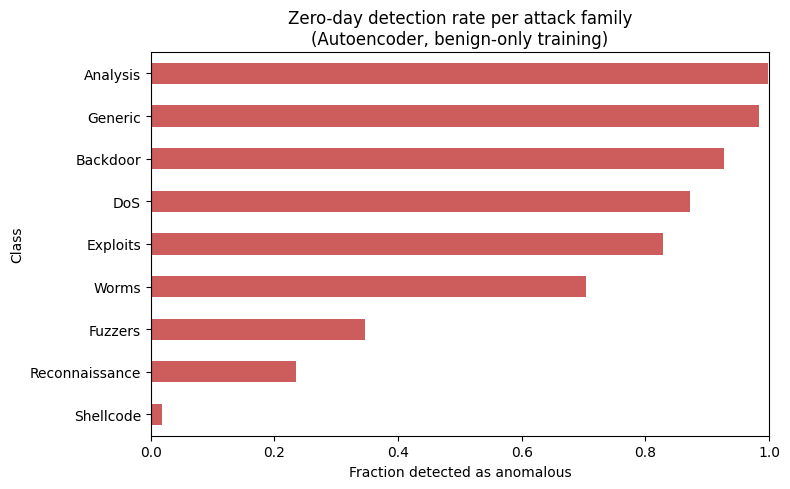

In [29]:
rows = []
for cls in range(len(class_names)):
    mask = (y_test_multi==cls)
    if mask.sum()==0:
        continue
    rows.append({"Class": class_names[cls], "Support": int(mask.sum()),
                 "Detected as anomaly": (y_pred_ae[mask]==1).mean()})

detect_df = pd.DataFrame(rows).set_index("Class")
print(detect_df.round(3).to_string())

attack_detect = detect_df.drop(index="Normal")["Detected as anomaly"].sort_values()
plt.figure(figsize=(8, 5))
attack_detect.plot(kind="barh", color="indianred")
plt.title("Zero-day detection rate per attack family\n(Autoencoder, benign-only training)")
plt.xlabel("Fraction detected as anomalous"); plt.xlim(0, 1)
plt.tight_layout(); plt.show()

#### 7.2 Results

| Model | Accuracy | Macro-F1 | Macro-Recall | FPR |
|---|---|---|---|---|
| Supervised binary RF (Section 5) | 0.871 | 0.865 | 0.858 | 0.270 |
| Autoencoder (one-class) | 0.843 | 0.843 | 0.850 | 0.084 |

Trained on normal traffic alone, the autoencoder reaches 0.843 macro-F1, close to the supervised Random Forest, and notably achieves the lowest false positive rate of any model (0.084), which is valuable in practice since false alarms are costly.

Per-family detection varies sharply:

| Attack family | Detected as anomaly |
|---|---|
| Analysis | 0.999 |
| Generic | 0.984 |
| Backdoor | 0.928 |
| DoS | 0.873 |
| Exploits | 0.828 |
| Worms | 0.705 |
| Fuzzers | 0.347 |
| Reconnaissance | 0.236 |
| Shellcode | 0.019 |

Some unseen families are caught almost perfectly (Analysis 0.999, Generic 0.984), while others are nearly invisible (Shellcode 0.019, Reconnaissance 0.236, Fuzzers 0.347). The classes that slip through are those whose traffic most resembles normal behaviour, which is exactly why a normality-based detector misses them. This quantifies the zero-day detection gap directly: detecting attacks without training on them works well for some attack types and fails for others.

## 8. Transformer-Based Detection

This section tests a Transformer encoder that uses self-attention, following the design of Akuthota and Bhargava (2025). Where the CNN-LSTM captures local sequential structure, self-attention lets every feature relate to every other feature directly. This adds a third modern architecture, evaluated against Random Forest and the CNN-LSTM models on the same split and metrics.

Two choices are inspired by Akuthota and Bhargava (2025): focal loss (Lin et al., 2017) to handle class imbalance by focusing training on hard examples, and correlation-based feature selection, keeping features whose absolute correlation with the target exceeds 0.5 (computed on training data only). As before, both tasks use the same fixed training conditions so the comparison stays fair.

In [ ]:
# Correlation-based feature selection
CORR_THRESHOLD = 0.5

# Correlate each processed feature with the multiclass target
corr_with_target = np.array([
    np.corrcoef(X_train[:, j], y_train_multi)[0, 1] for j in range(X_train.shape[1])
])
corr_with_target = np.nan_to_num(corr_with_target)
selected_mask = np.abs(corr_with_target)>CORR_THRESHOLD

if selected_mask.sum()<5:
    top = np.argsort(-np.abs(corr_with_target))[:15]
    selected_mask = np.zeros_like(selected_mask, dtype=bool); selected_mask[top] = True
    print(f"Threshold {CORR_THRESHOLD} kept <5 features; fell back to top-15 by |correlation|.")

X_train_fs = X_train[:, selected_mask]
X_test_fs = X_test[:,  selected_mask]

print(f"Features before selection: {X_train.shape[1]}")
print(f"Features after  selection: {X_train_fs.shape[1]} (|corr with target| > {CORR_THRESHOLD})")
sel_names = [feature_names[j].split('__', 1)[-1] for j in np.where(selected_mask)[0]]
print("Selected:", sel_names)

Threshold 0.5 kept <5 features; fell back to top-15 by |correlation|.
Features before selection: 194
Features after  selection: 15 (|corr with target| > 0.5)
Selected: ['rate', 'sttl', 'dttl', 'dload', 'ackdat', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_srv_dst', 'proto_ospf', 'proto_udp', 'proto_unas', 'service_dns', 'state_CON', 'state_INT']


In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(RANDOM_SEED)

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

class TransformerIDS(nn.Module):
    def __init__(self, n_features, n_classes, d_model=64, nhead=4, nlayers=2):
        super().__init__()
        self.embed = nn.Linear(1, d_model)
        self.pos = nn.Parameter(torch.randn(1, n_features, d_model) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, dropout=0.1, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=nlayers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Dropout(0.3), nn.Linear(d_model, n_classes))
    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.embed(x) + self.pos
        x = self.encoder(x)
        return self.head(x.mean(dim=1))

In [32]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

Xtr_flat = torch.tensor(X_train_fs, dtype=torch.float32)
Xte_flat = torch.tensor(X_test_fs,  dtype=torch.float32)
N_FEAT_FS = X_train_fs.shape[1]

def train_eval_transformer(y_tr_full, y_te, task, target_names, normal_label):
    n_classes = len(np.unique(y_tr_full))
    idx = np.arange(len(y_tr_full))
    tr_idx, va_idx = train_test_split(idx, test_size=0.10, stratify=y_tr_full, random_state=RANDOM_SEED)

    def loader(ii, shuffle):
        return DataLoader(TensorDataset(Xtr_flat[ii], torch.tensor(y_tr_full[ii], dtype=torch.long)), batch_size=512, shuffle=shuffle)
    tr_loader, va_loader = loader(tr_idx, True), loader(va_idx, False)

    model = TransformerIDS(N_FEAT_FS, n_classes).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    w = class_weights(y_tr_full[tr_idx])
    crit = FocalLoss(weight=w, gamma=2.0)

    print(f"\nTraining Transformer ({task})")
    for ep in range(15):
        model.train(); tr_loss = 0
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
            tr_loss += loss.item()
        if (ep+1)%3==0 or ep==0:
            model.eval(); va_loss = 0
            with torch.no_grad():
                for xb, yb in va_loader:
                    va_loss += crit(model(xb.to(device)), yb.to(device)).item()
            print(f"  epoch {ep+1:2d}/15  train={tr_loss/len(tr_loader):.4f}  "
                  f"val={va_loss/len(va_loader):.4f}")

    model.eval(); preds = []
    with torch.no_grad():
        for i in range(0, len(Xte_flat), 1024):
            preds.append(model(Xte_flat[i:i+1024].to(device)).argmax(1).cpu().numpy())
    y_pred = np.concatenate(preds)
    return evaluate_model("Transformer", task, y_te, y_pred, target_names=target_names, normal_label=normal_label)

train_eval_transformer(y_train_bin, y_test_bin, "Binary", ["Normal", "Attack"], normal_label=0)
cm_tf_multi = train_eval_transformer(y_train_multi, y_test_multi, "Multiclass", class_names, normal_label=6)


Training Transformer (Binary)
  epoch  1/15  train=0.0876  val=0.0597
  epoch  3/15  train=0.0470  val=0.0429
  epoch  6/15  train=0.0423  val=0.0413
  epoch  9/15  train=0.0418  val=0.0409
  epoch 12/15  train=0.0415  val=0.0404
  epoch 15/15  train=0.0418  val=0.0406

Transformer  -  Binary
Accuracy=0.8917 | Macro-F1=0.8913 | Macro-P=0.8907 | Macro-R=0.8944 | FPR=0.0792

Per-class report:
              precision    recall  f1-score   support

      Normal       0.85      0.92      0.88     37000
      Attack       0.93      0.87      0.90     45332

    accuracy                           0.89     82332
   macro avg       0.89      0.89      0.89     82332
weighted avg       0.89      0.89      0.89     82332


Training Transformer (Multiclass)
  epoch  1/15  train=1.4263  val=1.1167
  epoch  3/15  train=1.0722  val=1.0075
  epoch  6/15  train=1.0462  val=1.0274
  epoch  9/15  train=1.0269  val=0.9902
  epoch 12/15  train=1.0002  val=0.9747
  epoch 15/15  train=0.9962  val=0.9647

Tr

In [33]:
results_df = pd.DataFrame(results)
compare = results_df[results_df["Model"].isin(["Random Forest", "CNN-LSTM (Simple)", "CNN-LSTM (Deep)", "Transformer"])]
compare = compare.sort_values(["Task", "Macro-F1"], ascending=[True, False])
print(compare.to_string(index=False, columns=["Task", "Model", "Accuracy", "Macro-F1", "Macro-Recall", "FPR"], float_format=lambda x: f"{x:.4f}"))

      Task             Model  Accuracy  Macro-F1  Macro-Recall    FPR
    Binary   CNN-LSTM (Deep)    0.9081    0.9068        0.9055 0.1199
    Binary       Transformer    0.8917    0.8913        0.8944 0.0792
    Binary CNN-LSTM (Simple)    0.8774    0.8722        0.8658 0.2495
    Binary     Random Forest    0.8714    0.8652        0.8584 0.2702
Multiclass     Random Forest    0.7481    0.4895        0.5119 0.2343
Multiclass       Transformer    0.6123    0.3443        0.4547 0.4756
Multiclass CNN-LSTM (Simple)    0.6069    0.3374        0.5319 0.4193
Multiclass   CNN-LSTM (Deep)    0.6059    0.3082        0.4374 0.4216


### 8.1 Results

At the 0.5 correlation threshold fewer than five features qualified, so the selection fell back to the 15 features with the highest absolute correlation (`rate`, `sttl`, `dttl`, `dload`, `ackdat`, several connection counters, and a few one-hot protocol/service/state indicators).

| Task | Model | Accuracy | Macro-F1 | Macro-Recall | FPR |
|---|---|---|---|---|---|
| Binary | Transformer | 0.892 | 0.891 | 0.894 | 0.079 |
| Multiclass | Transformer | 0.612 | 0.344 | 0.455 | 0.476 |

On the binary task the Transformer performs strongly (macro-F1 0.891) and reaches a low false positive rate (0.079). On the multiclass task it drops to 0.344 macro-F1, in line with the CNN-LSTM models and below Random Forest. The full side-by-side comparison of all models is given in Section 9.1. Even with focal loss used to handle imbalance, the rare families stayed weak. This further demonstrates the well-known challenge in intrusion detection, where rare attack types are consistently the hardest to classify.

In [34]:
# Trainable parameter counts for the deep models
def n_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
n_classes_multi = len(class_names)
print(f"{'CNN-LSTM (Simple)':22s}: {n_params(CNN_LSTM_Simple(X_train.shape[1], n_classes_multi)):,}")
print(f"{'CNN-LSTM (Deep)':22s}: {n_params(CNN_LSTM_Deep(X_train.shape[1], n_classes_multi)):,}")
print(f"{'Transformer':22s}: {n_params(TransformerIDS(N_FEAT_FS, n_classes_multi)):,}")
print(f"{'Autoencoder':22s}: {n_params(AutoEncoder(X_train.shape[1])):,}")

CNN-LSTM (Simple)     : 75,658
CNN-LSTM (Deep)       : 290,570
Transformer           : 68,810
Autoencoder           : 30,354


## 9. Model Comparison and Discussion

This section brings all models together, compares per-class behaviour, and weighs performance against computational cost.

In [36]:
from sklearn.metrics import recall_score

def per_class_recall_from_cm(cm):
    with np.errstate(divide="ignore", invalid="ignore"):
        rec = np.diag(cm) / cm.sum(axis=1)
    return np.nan_to_num(rec)

recall_matrix = pd.DataFrame({
    "Random Forest": per_class_recall_from_cm(cm_rf_multi),
    "CNN-LSTM (Simple)": per_class_recall_from_cm(cm_simple_multi),
    "CNN-LSTM (Deep)": per_class_recall_from_cm(cm_deep_multi),
    "Transformer": per_class_recall_from_cm(cm_tf_multi),
    "Two-Tier RF": per_class_recall_from_cm(cm_twotier),
}, index=class_names).round(3)

support = pd.Series({class_names[c]: int((y_test_multi==c).sum()) for c in range(len(class_names))})
recall_matrix["Support"] = support
recall_matrix = recall_matrix.sort_values("Support", ascending=False)
print("Per-class recall across models (multiclass task):\n")
print(recall_matrix.to_string())

Per-class recall across models (multiclass task):

                Random Forest  CNN-LSTM (Simple)  CNN-LSTM (Deep)  Transformer  Two-Tier RF  Support
Normal                  0.766              0.581            0.578        0.524        0.730    37000
Generic                 0.966              0.956            0.962        0.961        0.966    18871
Exploits                0.675              0.458            0.337        0.419        0.678    11132
Fuzzers                 0.571              0.503            0.573        0.753        0.675     6062
DoS                     0.211              0.065            0.697        0.666        0.211     4089
Reconnaissance          0.793              0.343            0.006        0.197        0.793     3496
Analysis                0.040              0.000            0.000        0.084        0.043      677
Backdoor                0.261              0.863            0.027        0.002        0.237      583
Shellcode               0.632           

### 9.1 Overall performance

| Task | Model | Accuracy | Macro-F1 | Macro-Recall | FPR |
|---|---|---|---|---|---|
| Binary | CNN-LSTM (Deep) | 0.908 | 0.907 | 0.906 | 0.120 |
| Binary | Transformer | 0.892 | 0.891 | 0.894 | 0.079 |
| Binary | CNN-LSTM (Simple) | 0.877 | 0.872 | 0.866 | 0.250 |
| Binary | Random Forest | 0.871 | 0.865 | 0.858 | 0.270 |
| Binary | Autoencoder (one-class) | 0.843 | 0.843 | 0.850 | 0.084 |
| Binary | Logistic Regression | 0.836 | 0.829 | 0.825 | 0.282 |
| Multiclass | Random Forest | 0.748 | 0.490 | 0.512 | 0.234 |
| Multiclass | Two-Tier RF | 0.740 | 0.486 | 0.511 | 0.270 |
| Multiclass | Transformer | 0.612 | 0.344 | 0.455 | 0.476 |
| Multiclass | CNN-LSTM (Simple) | 0.607 | 0.337 | 0.532 | 0.419 |
| Multiclass | CNN-LSTM (Deep) | 0.606 | 0.308 | 0.437 | 0.422 |

The results show a clear, task-dependent split. The deep models perform better on the binary classification task, with the deep CNN-LSTM achieving best macro-F1 and the Transformer achieving best FPR. However, on the multiclass task, Random Forest is the strongest model by a wide margin, while every deep model drops to around 0.31 to 0.34 macro-F1, at or below Logistic Regression.

Accuracy also hides the multiclass difficulty: Random Forest reaches 0.748 accuracy but only 0.490 macro-F1, which is why per-class and macro metrics are used.

### 9.2 Per-class behaviour

The per-class recall table shows that no model handles the rare families well, but they fail in different ways. The large, well-separated classes are reliable everywhere: Generic stays near 0.96 across all models, and Normal stays moderate to high. The trouble is concentrated in the rare and overlapping classes.

Analysis is essentially undetectable by every model (recall from 0.00 to 0.08). For other rare classes such as Backdoor, DoS, and Worms, the deep models sometimes reach high recall, but at the cost of very low precision: for example the simple CNN-LSTM reaches 0.86 recall on Backdoor while its F1 is only 0.11, meaning it over-predicts that class. Random Forest and the two-tier model instead give the most balanced and trustworthy per-class behaviour overall.

The takeaway is that the rare-class problem is driven by the data, not by the choice of architecture. The same families that overlapped in the Section 4 separability view are the ones that fail here, across classical, hybrid, attention-based, and hierarchical models alike.

### 9.3 Computational cost

| Model | Trainable parameters |
|---|---|
| CNN-LSTM (Deep) | 290,570 |
| CNN-LSTM (Simple) | 75,658 |
| Transformer | 68,810 |
| Autoencoder | 30,354 |

Parameter count, which is a hardware-independent measure of model size, reinforces the performance findings. The deep CNN-LSTM carries about four times the parameters of the simple version, yet it was the weakest multiclass model, so the extra capacity was both unhelpful and counter-productive under fixed conditions. Random Forest and the two-tier model have no comparable weight-parameter count and train quickly on CPU, yet Random Forest gave the best multiclass result of any model. Taken together, the most accurate multiclass detector is also one of the cheapest, which indicates that model complexity is not the limiting factor on this dataset.

## 10. Gaps and Research Directions

This section discusses some gaps surfaced by the experiments and directions to explore further.

1. **Rare-attack and class-imbalance detection.** Analysis, Backdoor, Shellcode, and Worms were detected poorly across every architecture (Section 9.2), even with class weighting and focal loss. This is the most consistent gap in the study. Methods that target overlap between similar attack types should be explored rather than larger models, which Sections 6, 8, and 9 show do not help.

2. **Zero-day and unseen-attack detection.** The normal-only autoencoder (Section 7.2) achieved a very low false positive rate and caught several unseen families well, but missed others almost entirely (Shellcode 0.019, Reconnaissance 0.236). Detection of attacks never seen in training is therefore highly uneven. Future directions could focus on improving one-class and anomaly-based detection for stealthy attacks that resemble normal traffic. The adaptive, layered approach of Uddin et al. (2024) targets exactly this, and these results give solid motivation for it.

3. **Complexity does not equal capability.** Deep and attention-based models did not beat a Random Forest on multiclass detection, while costing far more parameters (Sections 9.1 and 9.3). The binary-task gains from deep models did not carry over to multiclass detection. Future work could attempt to improve deep model performance on the multiclass task, for example through hyperparameter tuning, imbalance-focused training strategies, or better handling of overlapping attack classes, and assessing whether the gains justify the higher computational cost compared with lightweight models.

4. **Task-matched hierarchical model.** The results show a split: deep models were strongest on the binary task (deep CNN-LSTM, macro-F1 0.907), while Random Forest was strongest on the multiclass family task (0.490). This suggests that, in a dual-tier architecture, matching each model to the task it does best could produce better results: a deep model for Tier 1 (Normal vs Attack) and a Random Forest for Tier 2 (attack family). Since Tier 1 already detects almost all attacks (Section 7.1), the main expected benefit would be a lower false positive rate rather than better rare-class detection, so this would be a promising design to test rather than a guaranteed improvement.

## 11. Limitations

- Single dataset: All results are on UNSW-NB15, so they may not generalise to other datasets.
- Fixed training conditions: The deep models used identical, untuned settings, so every model is compared under the same conditions. This gives a fair comparison under a fixed budget rather than a comparison of each model's best-achievable performance, since deep models in particular might improve with model-specific tuning.

## 12. Conclusion

This study carried out hands-on experiments with machine-learning-based intrusion detection on UNSW-NB15, comparing classical baselines, hybrid CNN-LSTM models, a Transformer, a two-tier cascade, and a one-class autoencoder. A few findings stood out. Rare and overlapping attack families resist detection regardless of architecture. Added model complexity did not improve multiclass detection, and a simple Random Forest remained the strongest model there while costing the least. An autoencoder trained only on normal traffic detected some unseen attacks very well but missed stealthy ones, and did so with a very low false alarm rate. Together these results point most clearly toward rare-attack detection and zero-day detection as the most promising directions for further work.

## References

[1] N. Moustafa and J. Slay, "UNSW-NB15: A Comprehensive Data Set for Network Intrusion Detection Systems (UNSW-NB15 Network Data Set)," in *2015 Military Communications and Information Systems Conference (MilCIS)*, 2015, pp. 1-6, doi: 10.1109/MilCIS.2015.7348942.

[2] M. Tavallaee, E. Bagheri, W. Lu, and A. A. Ghorbani, "A Detailed Analysis of the KDD CUP 99 Data Set," in *2009 IEEE Symposium on Computational Intelligence for Security and Defense Applications (CISDA)*, 2009, pp. 1-6, doi: 10.1109/CISDA.2009.5356528.

[3] G. Engelen, V. Rimmer, and W. Joosen, "Troubleshooting an Intrusion Detection Dataset: The CICIDS2017 Case Study," in *2021 IEEE Security and Privacy Workshops (SPW)*, 2021, pp. 7-12, doi: 10.1109/SPW53761.2021.00009.

[4] M. A. Bouke and A. Abdullah, "An empirical study of pattern leakage impact during data preprocessing on machine learning-based intrusion detection models reliability," *Expert Systems with Applications*, vol. 230, art. 120715, 2023, doi: 10.1016/j.eswa.2023.120715.

[5] N. Farnaaz and M. A. Jabbar, "Random Forest Modeling for Network Intrusion Detection System," *Procedia Computer Science*, vol. 89, pp. 213-217, 2016, doi: 10.1016/j.procs.2016.06.047.

[6] A. Halbouni, T. S. Gunawan, M. H. Habaebi, M. Halbouni, M. Kartiwi, and R. Ahmad, "CNN-LSTM: Hybrid Deep Neural Network for Network Intrusion Detection System," *IEEE Access*, vol. 10, pp. 99837-99849, 2022, doi: 10.1109/ACCESS.2022.3206425.

[7] M. A. Uddin, S. Aryal, M. R. Bouadjenek, M. Al-Hawawreh, and M. A. Talukder, "A Dual-Tier Adaptive One-Class Classification IDS for Emerging Cyberthreats," *Computer Communications*, vol. 229, art. 108006, 2025, doi: 10.1016/j.comcom.2024.108006.

[8] K. Sadaf and J. Sultana, "Intrusion Detection Based on Autoencoder and Isolation Forest in Fog Computing," *IEEE Access*, vol. 8, pp. 167059-167068, 2020, doi: 10.1109/ACCESS.2020.3022855.

[9] U. C. Akuthota and L. Bhargava, "Transformer-Based Intrusion Detection for IoT Networks," *IEEE Internet of Things Journal*, vol. 12, no. 5, pp. 6062-6067, 2025, doi: 10.1109/JIOT.2025.3525494.

[10] T.-Y. Lin, P. Goyal, R. Girshick, K. He, and P. Dollár, "Focal Loss for Dense Object Detection," *IEEE Transactions on Pattern Analysis and Machine Intelligence*, vol. 42, no. 2, pp. 318-327, 2020, doi: 10.1109/TPAMI.2018.2858826.